In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

2026-03-18 18:21:37.661920: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773858098.074764      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773858098.196809      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773858099.219560      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773858099.219605      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773858099.219608      24 computation_placer.cc:177] computation placer alr

In [2]:
train_path = '/kaggle/input/datasets/adlinhedilisyam/test-deepfake/dataset_split/train'
val_path   = '/kaggle/input/datasets/adlinhedilisyam/test-deepfake/dataset_split/val'
test_path  = '/kaggle/input/datasets/adlinhedilisyam/test-deepfake/dataset_split/test'

In [3]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    fill_mode='nearest'
)
val_gen   = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen  = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(299, 299),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=(299, 299),
    batch_size=32,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(299, 299),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 1428 images belonging to 2 classes.
Found 306 images belonging to 2 classes.
Found 307 images belonging to 2 classes.


In [4]:
base_model = Xception(weights='imagenet', include_top=False, input_shape=(299,299,3))

base_model.trainable = False  # freeze base model initially

from tensorflow.keras.layers import BatchNormalization

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1773858135.702143      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773858135.708427      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 74, 74,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add[0][0]       

 Total params: 21,427,241 (81.74 MB)

 Trainable params: 561,665 (2.14 MB)

 Non-trainable params: 20,865,576 (79.60 MB)

In [5]:
from sklearn.utils.class_weight import compute_class_weight

labels = train_data.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.0625), 1: np.float64(0.9444444444444444)}


In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
]

In [7]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weight_dict
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1773858148.784271      91 service.cc:152] XLA service 0x7e6d5803fe40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773858148.784313      91 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773858148.784320      91 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773858150.313769      91 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-18 18:22:37.578695: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv %cudnn-conv.78 = (f32[32,128,147,147]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,147,147]{3,2,1,0} %bitcast.8146, f32[128,1,3,3]{3,2,1,0} %bitcast.8150), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=128, custom_call_target="__cudnn$convForward", metadata={op_type="DepthwiseConv2dNative" op_name="functional_1/block2_sepconv2_1/separable_conv2d/depthwise" 

24/45 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.5204 - loss: 0.9169

2026-03-18 18:23:39.549382: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:23:39.780874: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:23:40.583181: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:23:40.823923: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:23:41.835714: E external/local_xla/xla/stream_

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5192 - loss: 0.9233

2026-03-18 18:24:46.398568: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:24:46.634354: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:24:47.446546: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:24:47.681589: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:24:48.685833: E external/local_xla/xla/stream_

45/45 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.5192 - loss: 0.9231 - val_accuracy: 0.5327 - val_loss: 0.6968
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.5721 - loss: 0.7967 - val_accuracy: 0.4804 - val_loss: 0.7058
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.5981 - loss: 0.6800 - val_accuracy: 0.5229 - val_loss: 0.6919
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.6430 - loss: 0.6281 - val_accuracy: 0.5425 - val_loss: 0.6879
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.6956 - loss: 0.5719 - val_accuracy: 0.5229 - val_loss: 0.6999
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.6667 - loss: 0.6069 - val_accuracy: 0.5196 - val_loss: 0.7028
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.7174 - loss: 0.5580 - val_accuracy: 0.5425 - val_loss: 0.7103
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.7216 - loss: 0.5289 - val_accuracy: 0.5359 - val_loss: 0.7622
Ep

In [8]:
for layer in base_model.layers[-40:]:   
    layer.trainable = True

In [9]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=45,                         
    class_weight=class_weight_dict
)

Epoch 1/45


2026-03-18 18:41:15.740768: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:41:15.885561: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:41:16.722296: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:41:16.860978: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:41:17.337075: E external/local_xla/xla/stream_

 1/45 ━━━━━━━━━━━━━━━━━━━━ 24:13 33s/step - accuracy: 0.6000 - loss: 0.7641

2026-03-18 18:41:38.199584: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:41:38.355455: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:41:39.943606: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:41:40.082751: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:41:40.822262: E external/local_xla/xla/stream_

45/45 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.7107 - loss: 0.6249 - val_accuracy: 0.5654 - val_loss: 1.0093
Epoch 2/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.7701 - loss: 0.5093 - val_accuracy: 0.5948 - val_loss: 0.9674
Epoch 3/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.7615 - loss: 0.4967 - val_accuracy: 0.5948 - val_loss: 0.9608
Epoch 4/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.7764 - loss: 0.4659 - val_accuracy: 0.5686 - val_loss: 0.9600
Epoch 5/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8083 - loss: 0.4425 - val_accuracy: 0.5817 - val_loss: 0.9461
Epoch 6/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.7792 - loss: 0.4498 - val_accuracy: 0.5850 - val_loss: 0.9229
Epoch 7/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8171 - loss: 0.4109 - val_accuracy: 0.5850 - val_loss: 0.9147
Epoch 8/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8286 - loss: 0.3720 - val_accuracy: 0.5980 - val_loss: 0.9205
Ep

In [11]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.6343 - loss: 1.1128

2026-03-18 19:21:00.776715: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 19:21:01.014435: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 19:21:01.799851: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 19:21:02.040127: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 19:21:02.965808: E external/local_xla/xla/stream_

10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.6303 - loss: 1.1170
Test Accuracy: 0.6123778223991394


10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step


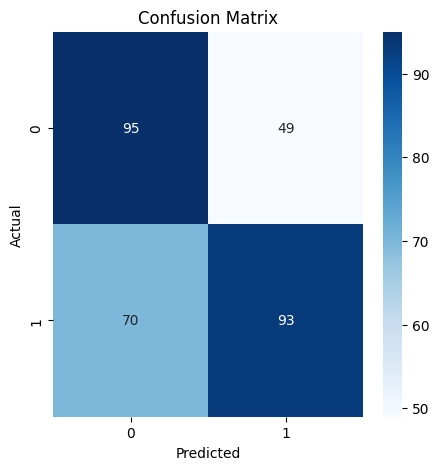

In [12]:
y_pred = model.predict(test_data)
y_pred_classes = (y_pred > 0.5).astype(int).ravel()
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [13]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.58      0.66      0.61       144
           1       0.65      0.57      0.61       163

    accuracy                           0.61       307
   macro avg       0.62      0.62      0.61       307
weighted avg       0.62      0.61      0.61       307



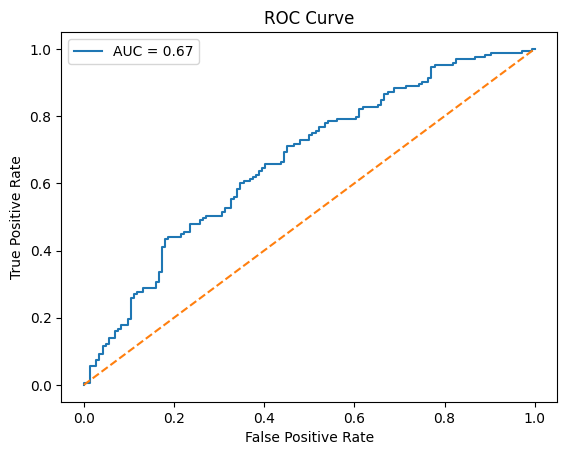

In [14]:
fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

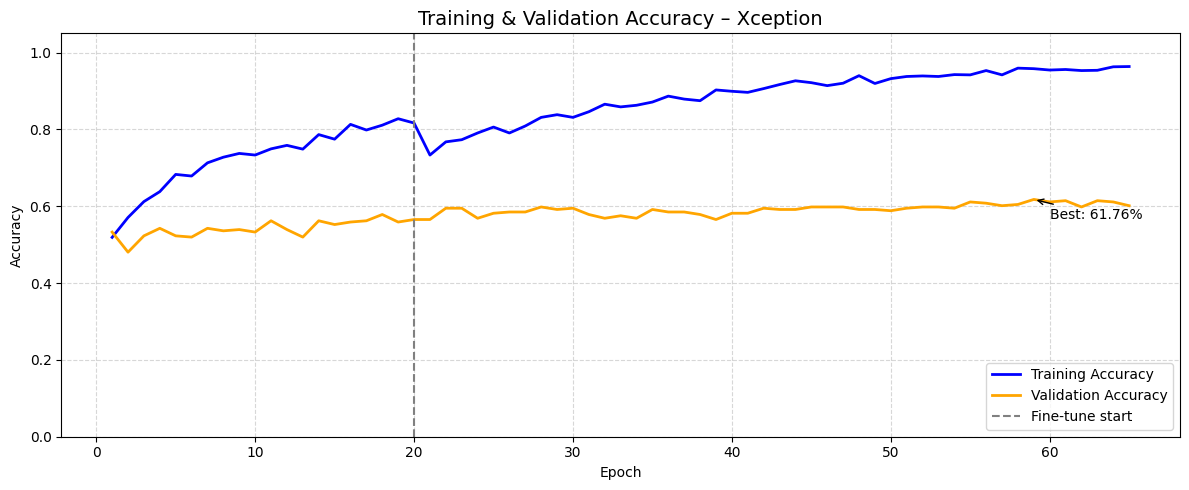

Best Training Accuracy  : 96.36%
Best Validation Accuracy: 61.76%
Best Val Accuracy at Epoch 59


In [ ]:
# Accuracy Line Chart

import matplotlib.pyplot as plt

acc  = history.history['accuracy']  + history2.history['accuracy']
vacc = history.history['val_accuracy'] + history2.history['val_accuracy']
epochs_range = range(1, len(acc) + 1)
phase2_start = len(history.history['accuracy'])  

plt.figure(figsize=(12, 5))

plt.plot(epochs_range, acc,  label='Training Accuracy',   color='blue',   linewidth=2)
plt.plot(epochs_range, vacc, label='Validation Accuracy', color='orange', linewidth=2)

plt.axvline(x=phase2_start, color='grey', linestyle='--', linewidth=1.5, label='Fine-tune start')

best_val_epoch = int(np.argmax(vacc)) + 1
best_val_acc   = max(vacc)
plt.annotate(
    f'Best: {best_val_acc*100:.2f}%',
    xy=(best_val_epoch, best_val_acc),
    xytext=(best_val_epoch + 1, best_val_acc - 0.05),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10
)

plt.title('Training & Validation Accuracy – Xception', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1.05])
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Best Training Accuracy  : {max(acc)*100:.2f}%")
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"Best Val Accuracy at Epoch {best_val_epoch}")

In [16]:
model.save("deepfake_xception_model.keras")